# §5.3 — Bicapa estratificada: análisis completo de las dos campañas

Dos campañas con **las mismas dos especies**, **las mismas fracciones de volumen** y **las mismas
profundidades absolutas de interfaz**; lo único que cambia es cuál de los dos medios recibe la luz.

| | entrada | fondo | $\ell^*_{\rm ent}$ | $\ell^*_{\rm fondo}$ |
|---|---|---|---|---|
| `normal` | 35 nm | 75 nm | 117.94 µm | 23.16 µm |
| `REV`    | 75 nm | 35 nm | 23.16 µm  | 117.94 µm |

Ambos scripts fijan `Z_INTERFACES = [m * 117.94 µm]`, así que el espesor **en unidades de transporte
del medio de entrada** difiere entre campañas por el factor $\ell^*_{35}/\ell^*_{75} = 5.09$. Esa es
la variable física, y todo el notebook la usa: $m_{\rm loc} = d/\ell^*_{\rm ent}$.

| | Figura | Afirmación |
|---|---|---|
| A1 | gate cruzado | Los límites de cada campaña reproducen los homogéneos — y se validan entre sí |
| L1 | familias de perfiles | Estructura de dos escalas en ambos órdenes |
| L2 | autosimilitud | No existe $\ell^*$ efectivo en ninguno de los dos órdenes (control: §5.2 sí) |
| L3 | $\rho$ y $S$ vs $m_{\rm loc}$ | El sobrepaso aparece solo con capa de entrada delgada: **test del mecanismo** |
| L4 | colapso de progreso | La profundidad de sondeo la fija el medio de entrada |
| L5 | $\Delta_{\rm orden}(\theta;z)$ | **El orden es un observable**: el apilamiento no conmuta |
| L6 | contraste temporal | Cambio de signo predicho; $t^*\propto d^2$ |

**Dos correcciones respecto al notebook exploratorio.** (1) La grilla temporal **no** es corta: el
script fija $t_{\max} = 40\,\tau^*$ del ancla $\max(\ell^*)$, es decir 20.9 ps, no 98 fs — la
reconstrucción anterior erraba por un factor $\sim\!200$ y sobre eso se descartó la ruta temporal.
Aquí se lee de `params_flat`. (2) El campo archivado `order` está fijo a `"normal"` en los dos
scripts; el orden se **deriva** de los radios archivados.

## 0 — Entorno y convenciones

In [2]:
import sys, os, pathlib, re
sys.path.append(os.path.abspath("../../"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass, field
from scipy import stats

from utils.loaders import load_sweep
from utils.styles import apply, TEXTWIDTH_IN, DOC_FONTSIZE, COL
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut, azimuthal_average

FIGDIR = pathlib.Path("figs_tesis_capas")
FIGDIR.mkdir(exist_ok=True)

save_path       = "/Users/niaggar/Results"
FOLDER_NORMAL   = "study_two_layers__PLIN__beam2500"
FOLDER_REVERSE  = "study_two_layers_REV__PLIN__beam2500"
FOLDER_MIXTURE  = "study_mixture_layer__PLIN__beam2500"

N_MEDIUM, WAVELENGTH = 1.33, 0.514
k = 2 * np.pi * N_MEDIUM / WAVELENGTH
eps = 1e-30

CONV = dict(
    phi_main       = 0,
    channel_main   = "co",
    th_full_mrad   = 6.0,
    th_apex_mrad   = 1.0,
    q_min_baseline = 25.0,
    n_apex_bins    = 3,
    x_lo           = 0.25,     # niveles del invariante de forma S
    x_hi           = 0.75,
    conf           = 0.975,
    snr_min_time   = 5.0,
)
PHI, CH = CONV["phi_main"], CONV["channel_main"]


def t_ci(n, conf=CONV["conf"]):
    return stats.t.ppf(conf, n - 1)


STYLE = {"normal":  dict(color=COL[0], marker="o", ls="-",  label="normal (35 nm entry)"),
         "reverse": dict(color=COL[1], marker="s", ls="--", label="reverse (75 nm entry)")}
print(f"t(0.975, 4) = {t_ci(5):.3f}")

t(0.975, 4) = 2.776


## 1 — Utilidades de reducción

Idénticas a §5.2 salvo por los escalares. `theta_level` y el invariante de forma sustituyen a la
FWHM: en un perfil de dos escalas el cruce a media altura salta entre rasgos y produce una serie sin
significado.

In [3]:
# ===========================================================================
# Stitching, linea base y perfiles
# ===========================================================================
def load_stitched(lstar, th1, g1, th2, g2, key, warn=0.05):
    theta_1 = th1[-1]
    ov = (th2 >= 0.9 * theta_1) & (th2 <= theta_1)
    if ov.any():
        resid = np.abs(g2[ov] - np.interp(th2[ov], th1, g1))
        if np.max(resid) > warn:
            print(f"[stitch WARN] {key}: max solape {np.max(resid):.3f}")
    keep2 = th2 > theta_1
    return (np.concatenate([th1, th2[keep2]]),
            k * lstar * np.concatenate([th1, th2[keep2]]),
            np.concatenate([g1, g2[keep2]]))


def tail_baseline(q, y, q_min=CONV["q_min_baseline"], n_min=5, frac=0.85):
    q, y = np.asarray(q), np.asarray(y)
    m = q > q_min
    if np.count_nonzero(m) >= n_min:
        return np.median(y[m])
    m = q >= frac * np.nanmax(q)
    if np.count_nonzero(m) < n_min:
        return np.median(y[np.argsort(q)[-n_min:]])
    return np.median(y[m])


def _raw(sweep, key, time_index):
    sw = sweep[key]
    p1 = cbs_profiles(sw.processed_cbs("farfield_cbs_1"), basis=linear,
                      time_index=time_index, reduce=phi_cut(PHI))
    p2 = cbs_profiles(sw.processed_cbs("farfield_cbs_2"), basis=linear,
                      time_index=time_index, reduce=phi_cut(PHI))
    return p1, p2


def profile_one(sweep, key, lstar, time_index=0):
    """(theta [rad], eta) de UNA replica, linea base a 1."""
    p1, p2 = _raw(sweep, key, time_index)
    E1 = (np.asarray(p1.coherent[CH]) + eps) / (np.asarray(p1.incoherent[CH]) + eps)
    E2 = (np.asarray(p2.coherent[CH]) + eps) / (np.asarray(p2.incoherent[CH]) + eps)
    theta, q, E = load_stitched(lstar, np.asarray(p1.theta), E1,
                                np.asarray(p2.theta), E2, key)
    return theta, E - tail_baseline(q, E) + 1.0


def profile_sum(sweep, keys, lstar, time_index=0):
    """(theta, eta) sumando intensidades sobre replicas: alto S/N.
    Obligatorio en el resuelto en tiempo, donde cada bin tiene pocos fotones."""
    Is = Bs = th1 = th2 = None
    for key in keys:
        p1, p2 = _raw(sweep, key, time_index)
        c1, c2 = np.asarray(p1.coherent[CH], float), np.asarray(p2.coherent[CH], float)
        b1, b2 = np.asarray(p1.incoherent[CH], float), np.asarray(p2.incoherent[CH], float)
        if Is is None:
            Is = [np.zeros_like(c1), np.zeros_like(c2)]
            Bs = [np.zeros_like(b1), np.zeros_like(b2)]
            th1, th2 = np.asarray(p1.theta), np.asarray(p2.theta)
        Is[0] += c1; Is[1] += c2; Bs[0] += b1; Bs[1] += b2
    keep2 = th2 > th1[-1]
    theta = np.concatenate([th1, th2[keep2]])
    I = np.concatenate([Is[0], Is[1][keep2]])
    B = np.concatenate([Bs[0], Bs[1][keep2]])
    E = (I + eps) / (B + eps)
    return theta, E - tail_baseline(k * lstar * theta, E) + 1.0

In [4]:
# ===========================================================================
# Escalares robustos a un perfil de dos escalas
# ===========================================================================
def peak_height(E, n=CONV["n_apex_bins"]):
    return float(np.median(np.asarray(E)[:n]))


def theta_level(theta, E, x, n=CONV["n_apex_bins"]):
    """Angulo [rad] donde el exceso eta-1 cae a la fraccion x de su apice.
    Para una familia de UNA sola escala, theta_x escala exactamente con esa
    escala sea cual sea la forma de linea: es la propiedad que explota L2."""
    E0 = peak_height(E, n)
    if E0 <= 1.0:
        return np.nan
    y = (np.asarray(E) - 1.0) / (E0 - 1.0)
    b = np.where(y < x)[0]
    b = b[b > 0]
    if len(b) == 0:
        return np.nan
    i = b[0]
    if y[i] == y[i - 1]:
        return np.nan
    return float(theta[i - 1] + (x - y[i - 1]) * (theta[i] - theta[i - 1]) / (y[i] - y[i - 1]))


def shape_invariant(theta, E):
    """S = theta_0.25 / theta_0.75. Razon de dos escalas del MISMO perfil, luego
    es independiente de la escala: cualquier medio con un unico l* da el mismo S.
    Verificado sobre familias sinteticas: varia 2.6 % al recorrer un factor 6 en l*."""
    a = theta_level(theta, E, CONV["x_lo"])
    b = theta_level(theta, E, CONV["x_hi"])
    return float(a / b) if (np.isfinite(a) and np.isfinite(b) and b > 0) else np.nan


def scalars_over_replicas(sweep, keys, lstar):
    """Media y SE sobre replicas de (eta0, theta_half [mrad], S)."""
    rows = []
    for key in keys:
        th, E = profile_one(sweep, key, lstar)
        rows.append([peak_height(E), theta_level(th, E, 0.5) * 1e3, shape_invariant(th, E)])
    A = np.asarray(rows, float)
    return A.mean(0), A.std(0, ddof=1) / np.sqrt(len(A))


U_GRID = np.linspace(0.15, 4.0, 200)


def normalized_shape(theta, E, u_grid=U_GRID):
    """f(u) = [eta-1]/[eta(0)-1] contra u = theta/theta_(1/2)."""
    E0, th = peak_height(E), theta_level(theta, E, 0.5)
    if not np.isfinite(th) or th <= 0 or E0 <= 1.0:
        return np.full_like(u_grid, np.nan)
    return np.interp(u_grid, theta / th, (np.asarray(E) - 1.0) / (E0 - 1.0))


def collapse_spread(curves):
    C = np.vstack(curves)
    return float(np.sqrt(np.nanmean((C - np.nanmean(C, 0)) ** 2)))

## 2 — Carga de las dos campañas

El campo `order` archivado está fijo a `"normal"` en ambos scripts (bug conocido), así que el orden
se **deriva** de `radius_top` / `radius_bot`. La grilla temporal se lee de `params_flat`; en la
convención interna de `luminis-mc` el tiempo de simulación es camino geométrico en µm, de modo que
$\tau^*$ en unidades de simulación es simplemente $\ell^*$, y $t/\tau^*_{\rm ent} = t_{\rm sim}/\ell^*_{\rm ent}$.

In [5]:
# ===========================================================================
# Carga de una campania completa
# ===========================================================================
@dataclass
class Layer:
    z: float
    m_loc: float           # d / l*_entrada  <- la variable fisica
    keys: list = field(default_factory=list)

    def __post_init__(self):
        self.keys = sorted(self.keys)


@dataclass
class Campaign:
    tag: str
    sweep: object
    order: str
    r_entry: float
    r_back: float
    l_entry: float
    l_back: float
    layers: list
    dt_sim: float
    t_max_sim: float
    n_time: int
    l_angle_anchor: float

    @property
    def m_loc(self):
        return np.array([L.m_loc for L in self.layers])

    @property
    def z(self):
        return np.array([L.z for L in self.layers])

    @property
    def R_inf(self):
        """Contraste asintotico del ancho tardio: >1 si el fondo es mas disperso."""
        return np.sqrt(self.l_entry / self.l_back)


def _get(p, names, default=np.nan):
    for nm in names:
        if nm in p:
            return float(p[nm])
    return default


def load_campaign(tag, folder):
    sw = load_sweep(folder, base_path=Path(save_path))
    by_z = {}
    for key in sw.keys():
        mm = re.search(r"z_interface_([0-9.]+)__rep(\d+)", key)
        if mm:
            by_z.setdefault(float(mm.group(1)), []).append(key)
        else:
            print(f"[{tag}] [skip] {key}")
    z_vals = sorted(by_z)
    p0 = sw[sorted(by_z[z_vals[0]])[0]].params_flat

    r_top, r_bot = _get(p0, ["radius_top"]), _get(p0, ["radius_bot"])
    l_top, l_bot = _get(p0, ["l_star_top"]), _get(p0, ["l_star_bot"])
    order = "reverse" if r_top > r_bot else "normal"     # DERIVADO: el campo archivado miente

    dt   = _get(p0, ["d_time", "time_grid.dt_sim", "time_grid_dt_sim", "dt_sim"])
    tmax = _get(p0, ["t_max", "time_grid.t_max_sim", "time_grid_t_max_sim", "t_max_sim"])
    n_t  = int(round(tmax / dt)) if np.isfinite(dt) and dt > 0 else 0

    # ancla ANGULAR del script = min(l*) = el cono mas ancho; fija donde empieza
    # la cola para tail_baseline y es identica en las dos campanias
    l_ang = _get(p0, ["l_star_angle_anchor"], min(l_top, l_bot))

    layers = [Layer(z=z, m_loc=z / l_top, keys=by_z[z]) for z in z_vals]
    return Campaign(tag=tag, sweep=sw, order=order, r_entry=r_top, r_back=r_bot,
                    l_entry=l_top, l_back=l_bot, layers=layers,
                    dt_sim=dt, t_max_sim=tmax, n_time=n_t, l_angle_anchor=l_ang)


CAMP = {}
for tag, folder in (("normal", FOLDER_NORMAL), ("reverse", FOLDER_REVERSE)):
    try:
        CAMP[tag] = load_campaign(tag, folder)
        print(f"[{tag}] cargada: {len(CAMP[tag].sweep.keys())} datasets, "
              f"{len(CAMP[tag].layers)} espesores")
    except Exception as err:
        print(f"[{tag}] no disponible: {err}")

try:
    SWEEP_MIX = load_sweep(FOLDER_MIXTURE, base_path=Path(save_path))
    print(f"[mezclas] cargada: {len(SWEEP_MIX.keys())} datasets")
except Exception as err:
    SWEEP_MIX = None
    print(f"[mezclas] no disponible: {err}")

[normal] cargada: 50 datasets, 10 espesores
[reverse] cargada: 50 datasets, 10 espesores
[mezclas] cargada: 60 datasets


In [6]:
# ===========================================================================
# Resumen del par y chequeos de consistencia
# ===========================================================================
for tag, C in CAMP.items():
    print(f"--- {tag} (order derivado = {C.order}) ---")
    print(f"  entrada r = {C.r_entry*1e3:.0f} nm  l* = {C.l_entry:8.2f} um")
    print(f"  fondo   r = {C.r_back*1e3:.0f} nm  l* = {C.l_back:8.2f} um")
    print(f"  R_inf predicho = sqrt(l*_ent/l*_fondo) = {C.R_inf:.3f}"
          f"   ({'ensancha' if C.R_inf > 1 else 'estrecha'} a tiempos tardios)")
    print(f"  grilla temporal: dt = {C.dt_sim:.2f} um   t_max = {C.t_max_sim:.1f} um"
          f"   n_bins = {C.n_time}")
    M_ent = C.t_max_sim / C.l_entry
    print(f"  ventana en tau*_entrada: M = {M_ent:.1f}"
          f"   -> alcance sqrt(2M/3) = {np.sqrt(2*M_ent/3):.2f} l*_ent")
    print(f"  z [um] y m_loc = z/l*_ent:")
    print("    " + "  ".join(f"{z:.0f}({mm:.2f})" for z, mm in zip(C.z, C.m_loc)))

# --- CHECK 1: el ancla temporal es max(l*), identico en ambas -> t_max igual --
if len(CAMP) == 2:
    a, b = CAMP["normal"], CAMP["reverse"]
    print(f"\n[check] t_max identico entre campanias: "
          f"{a.t_max_sim:.1f} vs {b.t_max_sim:.1f} um   "
          f"{'OK' if np.isclose(a.t_max_sim, b.t_max_sim, rtol=1e-3) else '[!] DIFIEREN'}")
    anchor = max(a.l_entry, a.l_back)
    print(f"[check] t_max / max(l*) = {a.t_max_sim/anchor:.1f}  (el script fija 40)")
    print(f"[check] profundidades absolutas identicas: "
          f"{'OK' if np.allclose(a.z, b.z, rtol=1e-3) else '[!] DIFIEREN'}")
    print(f"[check] factor de escala entre m_loc: {b.m_loc[0]/a.m_loc[0]:.2f}"
          f"  (esperado l*_35/l*_75 = {a.l_entry/b.l_entry:.2f})")
    print(f"[check] ancla angular: {a.l_angle_anchor:.2f} vs {b.l_angle_anchor:.2f} um   "
          f"{'OK' if np.isclose(a.l_angle_anchor, b.l_angle_anchor, rtol=1e-3) else '[!] DIFIEREN'}")

# ancla COMUN de la linea base: min(l*), el cono mas ancho, como en los scripts.
# Solo fija el eje q de tail_baseline; no reescala ningun perfil.
LREF = float(np.min([C.l_angle_anchor for C in CAMP.values()]))
print(f"\nLREF (ancla comun de linea base) = {LREF:.2f} um")

--- normal (order derivado = normal) ---
  entrada r = 35 nm  l* =   117.94 um
  fondo   r = 75 nm  l* =    23.16 um
  R_inf predicho = sqrt(l*_ent/l*_fondo) = 2.257   (ensancha a tiempos tardios)
  grilla temporal: dt = 47.18 um   t_max = 4717.6 um   n_bins = 100
  ventana en tau*_entrada: M = 40.0   -> alcance sqrt(2M/3) = 5.16 l*_ent
  z [um] y m_loc = z/l*_ent:
    12(0.10)  24(0.20)  59(0.50)  118(1.00)  177(1.50)  236(2.00)  354(3.00)  590(5.00)  826(7.00)  1179(10.00)
--- reverse (order derivado = reverse) ---
  entrada r = 75 nm  l* =    23.13 um
  fondo   r = 35 nm  l* =   117.70 um
  R_inf predicho = sqrt(l*_ent/l*_fondo) = 0.443   (estrecha a tiempos tardios)
  grilla temporal: dt = 47.08 um   t_max = 4708.0 um   n_bins = 100
  ventana en tau*_entrada: M = 203.6   -> alcance sqrt(2M/3) = 11.65 l*_ent
  z [um] y m_loc = z/l*_ent:
    12(0.51)  24(1.02)  59(2.54)  118(5.09)  177(7.63)  235(10.18)  353(15.27)  588(25.45)  824(35.62)  1177(50.89)

[check] t_max identico entre ca

## A1 — Gate cruzado: la pareja se da los controles a sí misma

El límite grueso de cada campaña es el medio de entrada homogéneo, y el límite delgado es el medio
de fondo homogéneo. Como las dos campañas intercambian los papeles, **cada límite tiene dos
realizaciones independientes**:

- 75 nm homogéneo $\;\leftarrow\;$ `normal` delgado ($d\to0$, fondo) **y** `REV` grueso ($d\to\infty$, entrada)
- 35 nm homogéneo $\;\leftarrow\;$ `normal` grueso (entrada) **y** `REV` delgado (fondo)

Si las dos realizaciones de un mismo límite coinciden, el pipeline es consistente y la comparación
está fundada. Si no, el desacuerdo localiza el problema sin salir del estudio.

[gate] 75 nm homogeneous: RMS = 2.25e-01   max = 2.60e-01
        normal/thin (m_loc=0.10): eta(0)=1.7269  th_1/2=1.020 mrad
        reverse/thick (m_loc=50.89): eta(0)=1.7418  th_1/2=3.830 mrad
[gate] 35 nm homogeneous: RMS = 2.68e-01   max = 2.99e-01
        normal/thick (m_loc=10.00): eta(0)=1.6162  th_1/2=1.192 mrad
        reverse/thin (m_loc=0.51): eta(0)=1.6446  th_1/2=8.460 mrad


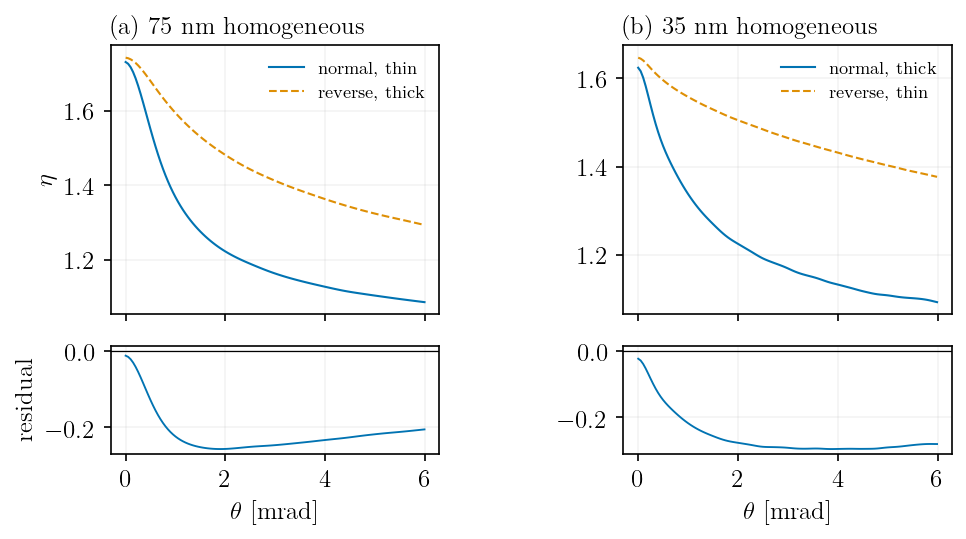


[!] 75 nm homogeneous: las dos realizaciones no coinciden (RMS 2.25e-01).
    Revisa, en este orden: (1) desde donde se mide z_interface,
    (2) si la capa de fondo es realmente semi-infinita en la corrida,
    (3) si el limite 'delgado' es de verdad opticamente delgado
        (comparalo con l_s de la capa de entrada, no con l*).

[!] 35 nm homogeneous: las dos realizaciones no coinciden (RMS 2.68e-01).
    Revisa, en este orden: (1) desde donde se mide z_interface,
    (2) si la capa de fondo es realmente semi-infinita en la corrida,
    (3) si el limite 'delgado' es de verdad opticamente delgado
        (comparalo con l_s de la capa de entrada, no con l*).


In [7]:
# ===========================================================================
# A1 -- gate cruzado entre campanias
# ===========================================================================
def limit_profile(C, which):
    """Perfil del limite 'thin' (fondo domina) o 'thick' (entrada domina).
    Ambos con el MISMO ancla de linea base: cualquier asimetria de procesamiento
    entre las dos realizaciones se leeria como desacuerdo fisico."""
    L = C.layers[0] if which == "thin" else C.layers[-1]
    th, E = profile_sum(C.sweep, L.keys, LREF)
    return th, E, L

GATE = {}
if len(CAMP) == 2:
    pairs = [("75 nm homogeneous", ("normal", "thin"), ("reverse", "thick")),
             ("35 nm homogeneous", ("normal", "thick"), ("reverse", "thin"))]

    apply(width_frac=1.0)
    fig, axes = plt.subplots(2, 2, figsize=(TEXTWIDTH_IN, 0.55 * TEXTWIDTH_IN),
                             sharex="col",
                             gridspec_kw={"height_ratios": [3, 1.2], "hspace": 0.08,
                                          "wspace": 0.25})
    for col, (name, (ta, wa), (tb, wb)) in enumerate(pairs):
        th_a, E_a, La = limit_profile(CAMP[ta], wa)
        th_b, E_b, Lb = limit_profile(CAMP[tb], wb)
        E_bi = np.interp(th_a, th_b, E_b)
        thm = th_a * 1e3
        w = thm <= CONV["th_full_mrad"]
        res = E_a - E_bi
        GATE[name] = dict(rms=float(np.sqrt(np.mean(res[w] ** 2))),
                          max=float(np.max(np.abs(res[w]))))
        print(f"[gate] {name}: RMS = {GATE[name]['rms']:.2e}   "
              f"max = {GATE[name]['max']:.2e}")
        print(f"        {ta}/{wa} (m_loc={La.m_loc:.2f}): eta(0)={peak_height(E_a):.4f}  "
              f"th_1/2={theta_level(th_a, E_a, 0.5)*1e3:.3f} mrad")
        print(f"        {tb}/{wb} (m_loc={Lb.m_loc:.2f}): eta(0)={peak_height(E_bi):.4f}  "
              f"th_1/2={theta_level(th_a, E_bi, 0.5)*1e3:.3f} mrad")

        axp, axr = axes[0, col], axes[1, col]
        axp.plot(thm[w], E_a[w], color=COL[0], lw=1.0, label=f"{ta}, {wa}")
        axp.plot(thm[w], E_bi[w], "--", color=COL[1], lw=1.0, label=f"{tb}, {wb}")
        axp.set_title(f"({'ab'[col]}) {name}", loc="left")
        axp.grid(alpha=0.15); axp.legend(fontsize="x-small", frameon=False)
        axr.axhline(0, c="k", lw=0.6)
        axr.plot(thm[w], res[w], color=COL[0], lw=0.9)
        axr.set_xlabel(r"$\theta$ [mrad]"); axr.grid(alpha=0.15)
        if col == 0:
            axp.set_ylabel(r"$\eta$"); axr.set_ylabel("residual")

    fig.savefig(FIGDIR / "A1_gate_cruzado.pdf", bbox_inches="tight")
    plt.show()

    for name, st in GATE.items():
        if st["rms"] > 5e-2:
            print(f"\n[!] {name}: las dos realizaciones no coinciden (RMS {st['rms']:.2e}).")
            print("    Revisa, en este orden: (1) desde donde se mide z_interface,")
            print("    (2) si la capa de fondo es realmente semi-infinita en la corrida,")
            print("    (3) si el limite 'delgado' es de verdad opticamente delgado")
            print("        (comparalo con l_s de la capa de entrada, no con l*).")

## L1 — Familias de perfiles, ambos órdenes

Sin ningún ajuste. Cada panel recorre el espesor en unidades del $\ell^*$ **de su propio medio de
entrada**, que es la variable ante la que el sistema responde.

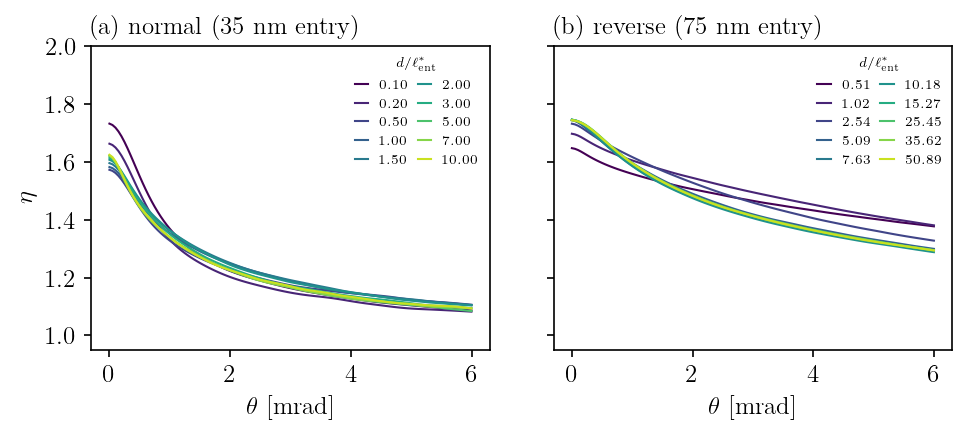

In [11]:
# ===========================================================================
# L1 -- familias eta(theta; m_loc)
# ===========================================================================
PROF = {}          # (tag, z) -> (theta, eta), linea base anclada a LREF comun
for tag, C in CAMP.items():
    for L in C.layers:
        PROF[(tag, L.z)] = profile_sum(C.sweep, L.keys, LREF)

apply(width_frac=1.0)
fig, axes = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.44 * TEXTWIDTH_IN),
                         sharey=True, gridspec_kw={"wspace": 0.12})
for ax, (tag, C) in zip(axes, CAMP.items()):
    ax.set_ylim(0.95, 2)
    cmap = plt.cm.viridis(np.linspace(0.0, 0.92, len(C.layers)))
    for c, L in zip(cmap, C.layers):
        th, E = PROF[(tag, L.z)]
        thm = th * 1e3
        w = thm <= CONV["th_full_mrad"]
        ax.plot(thm[w], E[w], color=c, lw=1.0, label=rf"${L.m_loc:.2f}$")
    ax.set_xlabel(r"$\theta$ [mrad]")
    ax.set_title(rf"({'ab'[list(CAMP).index(tag)]}) {STYLE[tag]['label']}", loc="left")
    ax.grid(False)
    ax.legend(ncol=2, columnspacing=0.8, handlelength=1.0, fontsize=6.5, frameon=False, title=r"$d/\ell^*_{\rm ent}$", title_fontsize=6.5)
axes[0].set_ylabel(r"$\eta$")
fig.savefig(FIGDIR / "L1_familias.pdf", bbox_inches="tight")
plt.show()

## L2 — Autosimilitud: ¿existe un $\ell^*$ efectivo?

Test **libre de modelo**. Se normaliza cada perfil en amplitud por $\eta(0)-1$ y en ángulo por su
propia semianchura:

$$\tilde f(u) = \frac{\eta(\theta)-1}{\eta(0)-1}, \qquad u = \theta/\theta_{1/2}.$$

Si el medio admite un $\ell^*$ efectivo, su perfil es $F(\theta/\ell^*_{\rm eff})$ para **alguna**
función $F$, y todas las curvas normalizadas coinciden exactamente, sea cual sea $F$. No se supone
AWM ni se usa el prefactor $C$. Sobre familias sintéticas de una sola escala que recorren un factor 6
en $\ell^*$ la dispersión residual es $8\times10^{-4}$; sobre familias de dos escalas sube a
$1.9\times10^{-2}$. Las once composiciones de §5.2 son el control positivo.

[L2] normal  : dispersion = 1.230e-02  (10 espesores)
[L2] reverse : dispersion = 1.415e-02  (10 espesores)
[L2] mixture : dispersion = 1.002e-03  (11 composiciones, control +)
     razon normal/mixture = 12.3x
     razon reverse/mixture = 14.1x


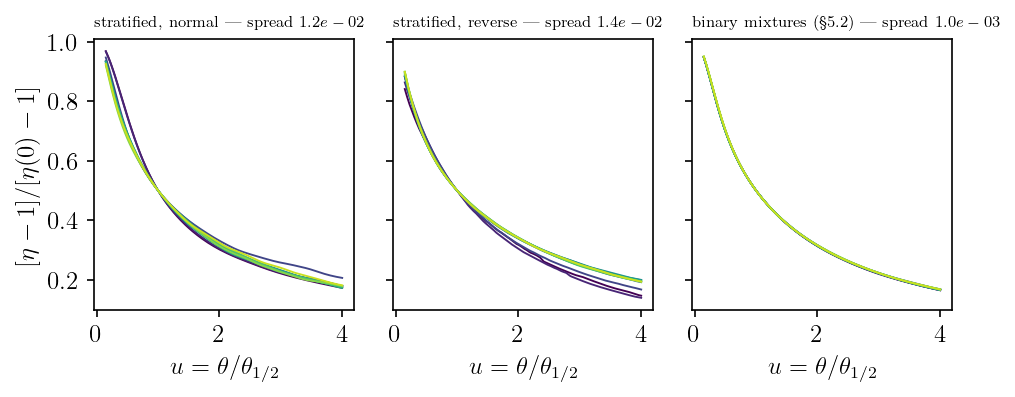

In [13]:
# ===========================================================================
# L2 -- colapso de autosimilitud: bicapas vs mezclas
# ===========================================================================
SHAPES, SPREAD = {}, {}
for tag, C in CAMP.items():
    SHAPES[tag] = [normalized_shape(*PROF[(tag, L.z)]) for L in C.layers]
    SPREAD[tag] = collapse_spread(SHAPES[tag])
    print(f"[L2] {tag:8s}: dispersion = {SPREAD[tag]:.3e}  ({len(C.layers)} espesores)")

SHAPES["mixture"], SPREAD["mixture"] = [], np.nan
if SWEEP_MIX is not None:
    try:
        for f in np.linspace(0.0, 1.0, 11):
            kk = sorted(x for x in SWEEP_MIX.keys() if f"fraction_{f:.2f}" in x)
            l_f = float(SWEEP_MIX[kk[0]].params_flat["transport_mean_free_path"])
            SHAPES["mixture"].append(normalized_shape(*profile_sum(SWEEP_MIX, kk, l_f)))
        SPREAD["mixture"] = collapse_spread(SHAPES["mixture"])
        print(f"[L2] mixture : dispersion = {SPREAD['mixture']:.3e}  (11 composiciones, control +)")
        for tag in CAMP:
            print(f"     razon {tag}/mixture = {SPREAD[tag]/SPREAD['mixture']:.1f}x")
    except Exception as err:
        print(f"[L2] control de mezclas no disponible: {err}")

panels = [t for t in ("normal", "reverse", "mixture") if SHAPES.get(t)]
apply(width_frac=1.0)
fig, axes = plt.subplots(1, len(panels), figsize=(TEXTWIDTH_IN, 0.40 * TEXTWIDTH_IN),
                         sharey=True, gridspec_kw={"wspace": 0.10})
axes = np.atleast_1d(axes)
titles = {"normal": "stratified, normal", "reverse": "stratified, reverse",
          "mixture": r"binary mixtures (§5.2)"}
for ax, tag in zip(axes, panels):
    cs = plt.cm.viridis(np.linspace(0, 0.92, len(SHAPES[tag])))
    for c, f in zip(cs, SHAPES[tag]):
        ax.plot(U_GRID, f, color=c, lw=0.9)
    ax.set_xlabel(r"$u = \theta/\theta_{1/2}$")
    ax.set_title(rf"{titles[tag]} — spread ${SPREAD[tag]:.1e}$", loc="left", fontsize=7.5)
    ax.grid(False)
axes[0].set_ylabel(r"$[\eta-1]/[\eta(0)-1]$")
fig.savefig(FIGDIR / "L2_autosimilitud.pdf", bbox_inches="tight")
plt.show()

## L3 — Escalares vs profundidad: test del mecanismo

En §5.2, $\rho = 2-\eta(0)$ era exactamente aditiva y quedaba siempre entre los dos constituyentes.
En la bicapa `normal` **sobrepasa a ambos**. La explicación propuesta es que una capa de entrada más
delgada que su propia longitud de transporte aporta dispersión simple sin aportar difusión, y la
atenuación del fondo se cancela en el cociente.

Esa explicación es **falsable con la campaña inversa**: en `REV` el medio de entrada es el
fuertemente dispersor, que difunde de inmediato, así que el régimen que produce el sobrepaso no
existe. **Predicción: en `REV` el sobrepaso desaparece o se reduce mucho.** Si se cumple, el
mecanismo deja de ser plausible y pasa a estar contrastado.

El panel (b) muestra el invariante de forma $S=\theta_{0.25}/\theta_{0.75}$, que es constante para
cualquier medio de una sola escala. Su excursión mide la "bi-escalaridad" del perfil sobre un
observable independiente de $\rho$.

[L3 normal  ] rho: 0.2731 (delgada) -> max 0.4311 en m_loc=0.50 -> 0.3838 (gruesa)
              sobrepaso sobre ambos extremos: +12.3 %   (+19.3 sigma)
              S: 5.171 / 7.484   maximo 7.675 en m_loc=0.50   excursion +48 %
[L3 reverse ] rho: 0.3558 (delgada) -> max 0.3558 en m_loc=0.51 -> 0.2587 (gruesa)
              sobrepaso sobre ambos extremos: +0.0 %   (+0.0 sigma)
              S: 8.447 / 8.994   maximo 9.364 en m_loc=7.63   excursion +11 %

[L3] control de una sola escala (§5.2): S = 6.215 +/- 0.035  (0.6 %)


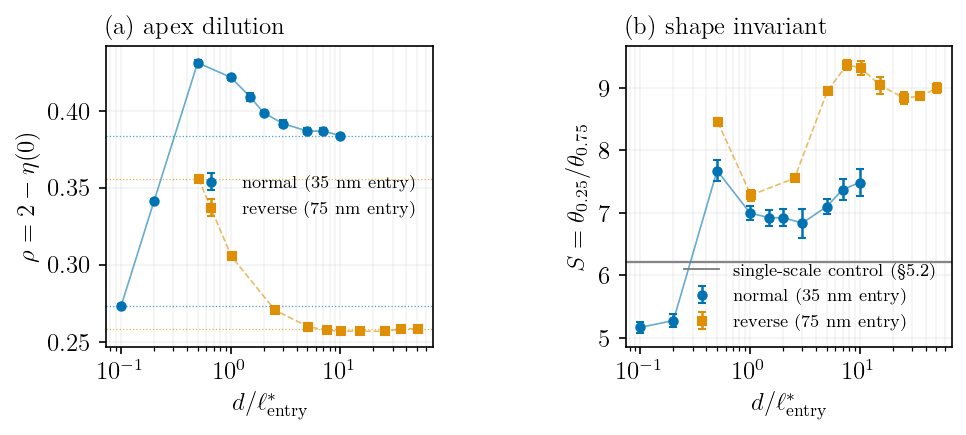

In [14]:
# ===========================================================================
# L3 -- rho(m_loc) y S(m_loc) en ambos ordenes
# ===========================================================================
SCAL = {}
for tag, C in CAMP.items():
    mu, se = zip(*[scalars_over_replicas(C.sweep, L.keys, LREF) for L in C.layers])
    MU, SE = np.asarray(mu), np.asarray(se)
    SCAL[tag] = dict(m=C.m_loc, eta0=MU[:, 0], s_eta0=SE[:, 0],
                     th=MU[:, 1], s_th=SE[:, 1], S=MU[:, 2], s_S=SE[:, 2],
                     rho=2.0 - MU[:, 0], s_rho=SE[:, 0])

OVER = {}
for tag, D in SCAL.items():
    r, sr = D["rho"], D["s_rho"]
    i = int(np.argmax(r))
    lim = max(r[0], r[-1])
    z = (r[i] - lim) / np.sqrt(sr[i] ** 2 + max(sr[0], sr[-1]) ** 2)
    OVER[tag] = dict(i=i, m=D["m"][i], rho_max=r[i], over_pct=100 * (r[i] / lim - 1), z=z)
    print(f"[L3 {tag:8s}] rho: {r[0]:.4f} (delgada) -> max {r[i]:.4f} en m_loc={D['m'][i]:.2f}"
          f" -> {r[-1]:.4f} (gruesa)")
    print(f"              sobrepaso sobre ambos extremos: {OVER[tag]['over_pct']:+.1f} %"
          f"   ({z:+.1f} sigma)")
    j = int(np.nanargmax(D["S"]))
    print(f"              S: {D['S'][0]:.3f} / {D['S'][-1]:.3f}"
          f"   maximo {D['S'][j]:.3f} en m_loc={D['m'][j]:.2f}"
          f"   excursion {100*(D['S'][j]/min(D['S'][0], D['S'][-1])-1):+.0f} %")

S_MIX = np.array([])
if SWEEP_MIX is not None:
    try:
        vals = []
        for f in np.linspace(0.0, 1.0, 11):
            kk = sorted(x for x in SWEEP_MIX.keys() if f"fraction_{f:.2f}" in x)
            l_f = float(SWEEP_MIX[kk[0]].params_flat["transport_mean_free_path"])
            vals.append(shape_invariant(*profile_sum(SWEEP_MIX, kk, l_f)))
        S_MIX = np.asarray(vals)
        print(f"\n[L3] control de una sola escala (§5.2): S = {np.nanmean(S_MIX):.3f}"
              f" +/- {np.nanstd(S_MIX, ddof=1):.3f}"
              f"  ({100*np.nanstd(S_MIX, ddof=1)/np.nanmean(S_MIX):.1f} %)")
    except Exception as err:
        print(f"[L3] control de mezclas no disponible: {err}")

apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.44 * TEXTWIDTH_IN),
                               gridspec_kw={"wspace": 0.28})
for tag, D in SCAL.items():
    st = STYLE[tag]
    ax1.errorbar(D["m"], D["rho"], D["s_rho"], fmt=st["marker"], ms=4, capsize=2,
                 color=st["color"], ls="none", label=st["label"])
    ax1.plot(D["m"], D["rho"], st["ls"], color=st["color"], lw=0.8, alpha=0.6)
    ax1.axhline(D["rho"][0],  ls=":", c=st["color"], lw=0.6, alpha=0.7)
    ax1.axhline(D["rho"][-1], ls=":", c=st["color"], lw=0.6, alpha=0.7)
    ax2.errorbar(D["m"], D["S"], D["s_S"], fmt=st["marker"], ms=4, capsize=2,
                 color=st["color"], ls="none", label=st["label"])
    ax2.plot(D["m"], D["S"], st["ls"], color=st["color"], lw=0.8, alpha=0.6)

if len(S_MIX):
    mu_s, sd_s = float(np.nanmean(S_MIX)), float(np.nanstd(S_MIX, ddof=1))
    ax2.axhline(mu_s, ls="-", color="gray", lw=0.9, label="single-scale control (§5.2)")
    ax2.axhspan(mu_s - sd_s, mu_s + sd_s, color="gray", alpha=0.15, lw=0)

for ax, yl, tt in ((ax1, r"$\rho = 2-\eta(0)$", "(a) apex dilution"),
                   (ax2, r"$S = \theta_{0.25}/\theta_{0.75}$", "(b) shape invariant")):
    ax.set_xscale("log")
    ax.set_xlabel(r"$d/\ell^*_{\rm entry}$")
    ax.set_ylabel(yl); ax.set_title(tt, loc="left")
    ax.grid(alpha=0.15, which="both")
    ax.legend(fontsize="x-small", frameon=False)

fig.savefig(FIGDIR / "L3_escalares.pdf", bbox_inches="tight")
plt.show()

## L4 — Colapso de progreso: la profundidad de sondeo la fija el medio de entrada

En profundidad absoluta las dos campañas saturan a $z$ muy distintos. Si lo que fija el alcance es
$\ell^*$ del medio de entrada, normalizando el progreso de cualquier escalar entre sus dos límites,

$$P(m_{\rm loc}) = \frac{X(m_{\rm loc}) - X_{\rm delgado}}{X_{\rm grueso} - X_{\rm delgado}},$$

las dos curvas deben caer una sobre otra contra $d/\ell^*_{\rm ent}$ aunque contra $z$ en µm estén
separadas por un factor $5.09$. Es una predicción sin parámetros: se cumple o no.

El panel (a) muestra el fracaso del reescalado en profundidad absoluta; el panel (b), el colapso en
unidades del medio de entrada.

[L4] solape en m_loc: [0.51, 10.00]  (40 puntos)
     |P_normal - P_REV|: RMS = 1.645   max = 2.619
     (0 = la profundidad de sondeo la fija solo el medio de entrada)
[L4] mismo contraste en z absoluto: RMS = 0.974


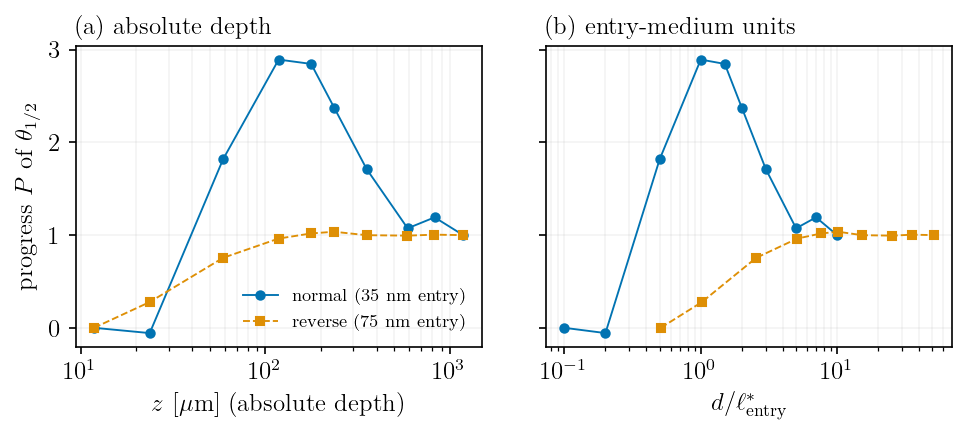

In [10]:
# ===========================================================================
# L4 -- colapso del progreso en unidades del medio de entrada
# ===========================================================================
def progress(x):
    x = np.asarray(x, float)
    return (x - x[0]) / (x[-1] - x[0])


apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.44 * TEXTWIDTH_IN),
                               sharey=True, gridspec_kw={"wspace": 0.12})
for tag, D in SCAL.items():
    st = STYLE[tag]
    P = progress(D["th"])
    ax1.plot(CAMP[tag].z, P, st["ls"], marker=st["marker"], ms=4,
             color=st["color"], lw=0.9, label=st["label"])
    ax2.plot(D["m"], P, st["ls"], marker=st["marker"], ms=4,
             color=st["color"], lw=0.9, label=st["label"])

# --- numero citable: discrepancia entre campanias en el solape de m_loc ----
if len(SCAL) == 2:
    a, b = SCAL["normal"], SCAL["reverse"]
    Pa, Pb = progress(a["th"]), progress(b["th"])
    lo = max(a["m"].min(), b["m"].min()); hi = min(a["m"].max(), b["m"].max())
    if hi > lo:
        mg = np.geomspace(lo, hi, 40)
        d = np.interp(mg, a["m"], Pa) - np.interp(mg, b["m"], Pb)
        print(f"[L4] solape en m_loc: [{lo:.2f}, {hi:.2f}]  ({len(mg)} puntos)")
        print(f"     |P_normal - P_REV|: RMS = {np.sqrt(np.mean(d**2)):.3f}   "
              f"max = {np.max(np.abs(d)):.3f}")
        print("     (0 = la profundidad de sondeo la fija solo el medio de entrada)")
    # mismo contraste en profundidad absoluta, para el panel (a)
    lo_z = max(a["m"].min()*CAMP["normal"].l_entry, b["m"].min()*CAMP["reverse"].l_entry)
    hi_z = min(a["m"].max()*CAMP["normal"].l_entry, b["m"].max()*CAMP["reverse"].l_entry)
    if hi_z > lo_z:
        zg = np.geomspace(lo_z, hi_z, 40)
        dz = np.interp(zg, CAMP["normal"].z, Pa) - np.interp(zg, CAMP["reverse"].z, Pb)
        print(f"[L4] mismo contraste en z absoluto: RMS = {np.sqrt(np.mean(dz**2)):.3f}")

ax1.set_xscale("log"); ax1.set_xlabel(r"$z$ [$\mu$m]  (absolute depth)")
ax1.set_ylabel(r"progress $P$ of $\theta_{1/2}$")
ax1.set_title("(a) absolute depth", loc="left")
ax1.grid(alpha=0.15, which="both"); ax1.legend(fontsize="x-small", frameon=False)
ax2.set_xscale("log"); ax2.set_xlabel(r"$d/\ell^*_{\rm entry}$")
ax2.set_title("(b) entry-medium units", loc="left")
ax2.grid(alpha=0.15, which="both")
fig.savefig(FIGDIR / "L4_colapso_progreso.pdf", bbox_inches="tight")
plt.show()

## L5 — El orden es un observable

Las dos campañas comparten especies, fracciones de volumen y profundidades absolutas de interfaz.
Lo único que cambia es cuál medio recibe la luz. Si el CBS admitiera cualquier descripción por
composición, ambas coincidirían. La diferencia a profundidad igualada

$$\Delta_{\rm orden}(\theta; z) = \eta_{\rm normal}(\theta; z) - \eta_{\rm REV}(\theta; z)$$

mide la **no conmutatividad del apilamiento**, y es una afirmación más fuerte que la ausencia de
medio efectivo: dice que el observable depende del orden, no solo de las cantidades presentes.

Escala de referencia: la brecha de Jensen de §5.2 vale $\sim\!4\times10^{-3}$.

[L5] pares por indice: 10
     desajuste de z: max 0.21 %


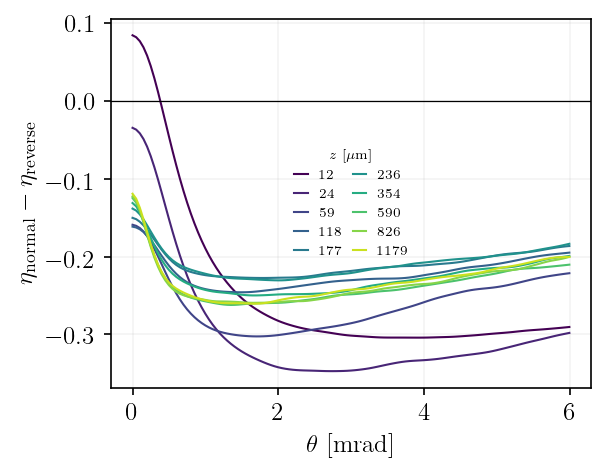

,z_normal,z_reverse,ext,theta_ext,rms
0,11.79,11.77,-0.3044,3.8934,0.2672
1,23.59,23.54,-0.3475,2.7453,0.3071
2,58.97,58.85,-0.3028,1.6971,0.2633
3,117.94,117.70,-0.2460,1.4975,0.2226
4,176.91,176.55,-0.2276,1.7970,0.2101
5,235.88,235.40,-0.2307,1.9966,0.2097
6,353.82,353.10,-0.2501,1.6472,0.2278
7,589.70,588.50,-0.2623,1.3477,0.2374
8,825.58,823.90,-0.2596,1.6472,0.2356
9,1179.40,1177.00,-0.2607,1.6971,0.2327


[L5] |Delta_orden| max = 0.348   en z = 24 um
     brecha de Jensen de 5.2 ~ 4e-3  ->  factor 87x


In [13]:
# ===========================================================================
# L5 -- no conmutatividad del orden  (emparejado por indice)
# ===========================================================================
if len(CAMP) == 2:
    A, B = CAMP["normal"], CAMP["reverse"]
    n_pair = min(len(A.layers), len(B.layers))
    print(f"[L5] pares por indice: {n_pair}")
    print(f"     desajuste de z: max {np.max(np.abs(A.z[:n_pair]-B.z[:n_pair])/A.z[:n_pair])*100:.2f} %")

    apply(width_frac=0.62)
    fig, ax = plt.subplots(figsize=(0.62 * TEXTWIDTH_IN, 0.48 * TEXTWIDTH_IN))
    cmap = plt.cm.viridis(np.linspace(0, 0.92, n_pair))
    rows = []
    for c, i in zip(cmap, range(n_pair)):
        th_a, E_a = PROF[("normal", A.layers[i].z)]
        th_b, E_b = PROF[("reverse", B.layers[i].z)]
        E_bi = E_b if (len(th_a) == len(th_b) and np.allclose(th_a, th_b)) \
            else np.interp(th_a, th_b, E_b)
        d, thm = E_a - E_bi, th_a * 1e3
        w = thm <= CONV["th_full_mrad"]
        ax.plot(thm[w], d[w], color=c, lw=1.0, label=rf"${A.z[i]:.0f}$")
        j = int(np.argmax(np.abs(d[w])))
        rows.append(dict(z_normal=A.z[i], z_reverse=B.z[i], ext=float(d[w][j]),
                         theta_ext=float(thm[w][j]), rms=float(np.sqrt(np.mean(d[w]**2)))))
    ax.axhline(0, c="k", lw=0.6)
    ax.set_xlabel(r"$\theta$ [mrad]")
    ax.set_ylabel(r"$\eta_{\rm normal}-\eta_{\rm reverse}$")
    ax.grid(alpha=0.15)
    ax.legend(ncol=2, columnspacing=0.8, handlelength=1.0, fontsize=6.5,
              frameon=False, title=r"$z$ [$\mu$m]", title_fontsize=6.5)
    fig.savefig(FIGDIR / "L5_orden.pdf", bbox_inches="tight")
    plt.show()

    df_ord = pd.DataFrame(rows)
    display(df_ord.round(4))
    if len(df_ord):
        i = df_ord["ext"].abs().idxmax()
        print(f"[L5] |Delta_orden| max = {df_ord['ext'].abs().max():.3f}"
              f"   en z = {df_ord.loc[i,'z_normal']:.0f} um")
        print(f"     brecha de Jensen de 5.2 ~ 4e-3  ->  factor "
              f"{df_ord['ext'].abs().max()/4e-3:.0f}x")

## L6 — Contraste temporal: cambio de signo predicho

Se mide $\theta_{1/2}(t)$ por bin temporal (intensidades sumadas sobre réplicas, con puerta de S/N)
y se forma el cociente contra la referencia de capa gruesa de la **misma** campaña,
$R_m(t) = \theta_{1/2,m}(t)/\theta_{1/2,\rm ref}(t)$.

La asíntota tardía es $R_\infty = \sqrt{\ell^*_{\rm ent}/\ell^*_{\rm fondo}}$, sin parámetros:

- `normal`: la luz empieza en el medio de $\ell^*$ grande y cruza al pequeño $\Rightarrow$ el cono se
  **ensancha**, $R_\infty = 2.26$.
- `REV`: al revés $\Rightarrow$ el cono se **estrecha**, $R_\infty = 0.44$.

Un cambio de signo del efecto, predicho antes de mirar. El tiempo de quiebre $t^*$ se localiza como
el primer cruce persistente del punto medio geométrico entre 1 y $R_{\rm late}$, y se contrasta con
$t^* = \alpha\,m_{\rm loc}^2\,\tau^*_{\rm ent}$, $\alpha = 3/2$.

In [14]:
# ===========================================================================
# L6 -- theta_(1/2)(t) por espesor, contraste tardio y t*
# ===========================================================================
TIME_STRIDE = 1


def noise_tail(theta, E, th_min=CONV["th_full_mrad"]):
    m = theta * 1e3 > th_min
    return float(np.std(E[m])) if np.count_nonzero(m) > 5 else np.inf


WID = {}
for tag, C in CAMP.items():
    for L in C.layers:
        ts, ws = [], []
        for it in range(1, C.n_time + 1, TIME_STRIDE):
            try:
                th, E = profile_sum(C.sweep, L.keys, LREF, time_index=int(it))
            except Exception:
                continue
            e0 = peak_height(E)
            if not np.isfinite(e0) or (e0 - 1.0) < CONV["snr_min_time"] * noise_tail(th, E):
                continue
            h = theta_level(th, E, 0.5)
            if np.isfinite(h):
                ts.append((it - 0.5) * C.dt_sim / C.l_entry)      # t / tau*_entrada
                ws.append(h * 1e3)
        WID[(tag, L.z)] = (np.asarray(ts), np.asarray(ws))
    print(f"[L6 {tag:8s}] bins validos por espesor: "
          f"{[len(WID[(tag, L.z)][0]) for L in C.layers]}")

[L6 normal  ] bins validos por espesor: [99, 99, 99, 99, 99, 99, 98, 99, 99, 99]
[L6 reverse ] bins validos por espesor: [99, 99, 99, 99, 99, 99, 99, 99, 99, 99]


[L6 normal  ] alpha ajustado = 1.31   (teoria 3/2)   (7 espesores)
            R_late: [1.95 1.89 1.72 1.57 1.43 1.35 1.17]   R_inf = 2.26
[L6 reverse ] alpha ajustado = 1.22   (teoria 3/2)   (6 espesores)
            R_late: [0.46 0.46 0.47 0.51 0.64 0.78]   R_inf = 0.44


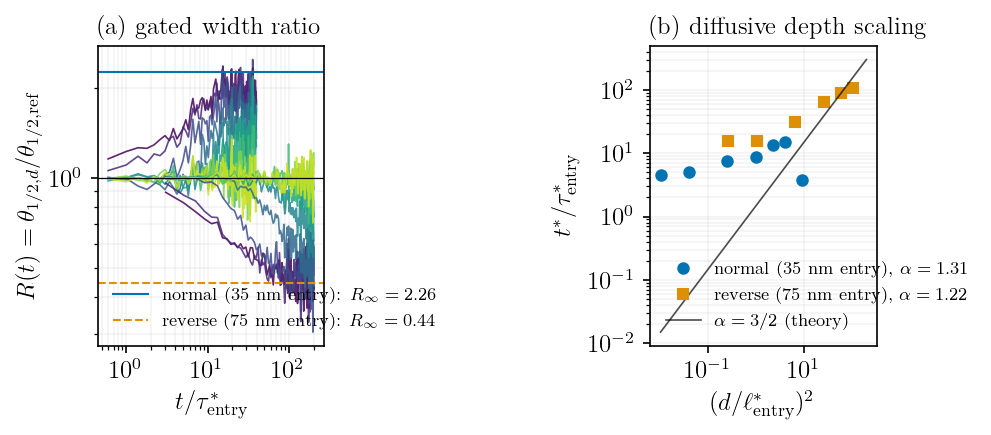

In [15]:
# ===========================================================================
# L6 -- figura: R(t) y t* vs m_loc^2
# ===========================================================================
ALPHA_TEO = 1.5
TSTAR = {tag: dict(m=[], t=[], R=[]) for tag in CAMP}

apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.44 * TEXTWIDTH_IN),
                               gridspec_kw={"wspace": 0.28})

for tag, C in CAMP.items():
    st = STYLE[tag]
    ts_r, ws_r = WID[(tag, C.layers[-1].z)]
    cmap = plt.cm.viridis(np.linspace(0, 0.92, len(C.layers) - 1))
    for c, L in zip(cmap, C.layers[:-1]):
        ts, ws = WID[(tag, L.z)]
        if len(ts) < 8 or len(ts_r) < 8:
            continue
        lo, hi = max(ts.min(), ts_r.min()), min(ts.max(), ts_r.max())
        msk = (ts >= lo) & (ts <= hi)
        if np.count_nonzero(msk) < 8:
            continue
        R = ws[msk] / np.interp(ts[msk], ts_r, ws_r)
        tR = ts[msk]
        ax1.plot(tR, R, "-", color=c, lw=0.8, alpha=0.85)

        n_late = max(3, len(R) // 5)
        R_late = float(np.median(R[-n_late:]))
        if abs(np.log(R_late)) < np.log(1.15):        # sin quiebre resoluble
            continue
        thr = np.exp(0.5 * np.log(R_late))            # punto medio geometrico
        cross = (np.abs(np.log(R)) > abs(np.log(thr))) & \
                (np.abs(np.log(np.roll(R, -1))) > abs(np.log(thr)))
        idx = np.where(cross)[0]
        if len(idx):
            TSTAR[tag]["m"].append(L.m_loc)
            TSTAR[tag]["t"].append(float(tR[idx[0]]))
            TSTAR[tag]["R"].append(R_late)

    ax1.axhline(C.R_inf, ls=st["ls"], color=st["color"], lw=1.0,
                label=rf"{st['label']}: $R_\infty={C.R_inf:.2f}$")

ax1.axhline(1.0, c="k", lw=0.6)
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$t/\tau^*_{\rm entry}$")
ax1.set_ylabel(r"$R(t)=\theta_{1/2,d}/\theta_{1/2,\rm ref}$")
ax1.set_title("(a) gated width ratio", loc="left")
ax1.grid(alpha=0.15, which="both"); ax1.legend(fontsize="x-small", frameon=False)

for tag in CAMP:
    T = TSTAR[tag]
    if not T["m"]:
        continue
    st = STYLE[tag]
    u = np.asarray(T["m"]) ** 2
    t = np.asarray(T["t"])
    a_fit = float(np.sum(u * t) / np.sum(u ** 2))
    print(f"[L6 {tag:8s}] alpha ajustado = {a_fit:.2f}   (teoria 3/2)"
          f"   ({len(u)} espesores)")
    print(f"            R_late: {np.round(T['R'], 2)}   R_inf = {CAMP[tag].R_inf:.2f}")
    ax2.plot(u, t, st["marker"], ms=5, color=st["color"],
             label=rf"{st['label']}, $\alpha={a_fit:.2f}$")

uu = np.geomspace(1e-2, 2e2, 50)
ax2.plot(uu, ALPHA_TEO * uu, "k-", lw=0.8, alpha=0.7, label=r"$\alpha=3/2$ (theory)")
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel(r"$(d/\ell^*_{\rm entry})^2$")
ax2.set_ylabel(r"$t^*/\tau^*_{\rm entry}$")
ax2.set_title("(b) diffusive depth scaling", loc="left")
ax2.grid(alpha=0.15, which="both"); ax2.legend(fontsize="x-small", frameon=False)

fig.savefig(FIGDIR / "L6_temporal.pdf", bbox_inches="tight")
plt.show()

## Tabla y números citables

In [16]:
# ===========================================================================
# Tabla -> CSV + filas LaTeX
# ===========================================================================
rows = []
for tag, C in CAMP.items():
    D = SCAL[tag]
    Tm = dict(zip(TSTAR[tag]["m"], TSTAR[tag]["t"]))
    Rl = dict(zip(TSTAR[tag]["m"], TSTAR[tag]["R"]))
    for i, L in enumerate(C.layers):
        rows.append(dict(order=tag, z_um=L.z, m_loc=L.m_loc,
                         eta0=D["eta0"][i], s_eta0=D["s_eta0"][i],
                         rho=D["rho"][i], s_rho=D["s_rho"][i],
                         theta_half_mrad=D["th"][i], s_theta_half=D["s_th"][i],
                         S_shape=D["S"][i], s_S=D["s_S"][i],
                         R_late=Rl.get(L.m_loc, np.nan),
                         tstar_tau=Tm.get(L.m_loc, np.nan)))
df = pd.DataFrame(rows)
df.to_csv(FIGDIR / "tabla_capas.csv", index=False)
display(df.round(4))


def pm(v, s, nd=4):
    return "--" if not np.isfinite(v) else rf"${v:.{nd}f} \pm {s:.{nd}f}$"


lines = ["    " + " & ".join([
    r["order"][:3], f"{r['z_um']:.0f}", f"{r['m_loc']:.2f}",
    pm(r["rho"], r["s_rho"], 4),
    pm(r["theta_half_mrad"], r["s_theta_half"], 3),
    pm(r["S_shape"], r["s_S"], 3),
    "--" if not np.isfinite(r["R_late"]) else f"{r['R_late']:.2f}",
]) + r" \\" for _, r in df.iterrows()]
(FIGDIR / "tabla_capas.tex").write_text("\n".join(lines))
print("\n".join(lines))

,order,z_um,m_loc,eta0,s_eta0,rho,s_rho,theta_half_mrad,s_theta_half,S_shape,s_S,R_late,tstar_tau
0,normal,11.79,0.1000,1.7269,0.0014,0.2731,0.0014,1.0199,0.0085,5.1711,0.0913,1.9465,4.6000
1,normal,23.59,0.2000,1.6586,0.0015,0.3414,0.0015,1.0100,0.0085,5.2805,0.0976,1.8916,5.0000
2,normal,58.97,0.5000,1.5689,0.0020,0.4311,0.0020,1.3355,0.0149,7.6755,0.1706,1.7225,7.4000
3,normal,117.94,1.0000,1.5784,0.0014,0.4216,0.0014,1.5218,0.0411,6.9978,0.1050,1.5689,8.6000
4,normal,176.91,1.5000,1.5909,0.0026,0.4091,0.0026,1.5137,0.0235,6.9216,0.1241,1.4276,13.4000
5,normal,235.88,2.0000,1.6014,0.0012,0.3986,0.0012,1.4317,0.0157,6.9238,0.1391,1.3542,15.0000
6,normal,353.82,3.0000,1.6084,0.0022,0.3916,0.0022,1.3168,0.0230,6.8372,0.2305,1.1741,3.8000
7,normal,589.70,5.0000,1.6133,0.0018,0.3867,0.0018,1.2061,0.0061,7.1004,0.1227,NaN,NaN
8,normal,825.58,7.0000,1.6133,0.0021,0.3867,0.0021,1.2266,0.0184,7.3731,0.1732,NaN,NaN
9,normal,1179.40,10.0000,1.6162,0.0013,0.3838,0.0013,1.1933,0.0127,7.4845,0.2199,NaN,NaN


    nor & 12 & 0.10 & $0.2731 \pm 0.0014$ & $1.020 \pm 0.009$ & $5.171 \pm 0.091$ & 1.95 \\
    nor & 24 & 0.20 & $0.3414 \pm 0.0015$ & $1.010 \pm 0.008$ & $5.281 \pm 0.098$ & 1.89 \\
    nor & 59 & 0.50 & $0.4311 \pm 0.0020$ & $1.335 \pm 0.015$ & $7.675 \pm 0.171$ & 1.72 \\
    nor & 118 & 1.00 & $0.4216 \pm 0.0014$ & $1.522 \pm 0.041$ & $6.998 \pm 0.105$ & 1.57 \\
    nor & 177 & 1.50 & $0.4091 \pm 0.0026$ & $1.514 \pm 0.023$ & $6.922 \pm 0.124$ & 1.43 \\
    nor & 236 & 2.00 & $0.3986 \pm 0.0012$ & $1.432 \pm 0.016$ & $6.924 \pm 0.139$ & 1.35 \\
    nor & 354 & 3.00 & $0.3916 \pm 0.0022$ & $1.317 \pm 0.023$ & $6.837 \pm 0.230$ & 1.17 \\
    nor & 590 & 5.00 & $0.3867 \pm 0.0018$ & $1.206 \pm 0.006$ & $7.100 \pm 0.123$ & -- \\
    nor & 826 & 7.00 & $0.3867 \pm 0.0021$ & $1.227 \pm 0.018$ & $7.373 \pm 0.173$ & -- \\
    nor & 1179 & 10.00 & $0.3838 \pm 0.0013$ & $1.193 \pm 0.013$ & $7.484 \pm 0.220$ & -- \\
    rev & 12 & 0.51 & $0.3558 \pm 0.0019$ & $8.451 \pm 0.116$ & $8.447 \pm 0.

In [17]:
# ===========================================================================
# Resumen citable
# ===========================================================================
print("=" * 74)
print("NUMEROS CITABLES 5.3 (bicapa, dos ordenes)")
print("=" * 74)
for tag, C in CAMP.items():
    print(f"  {tag:8s}: entrada r={C.r_entry*1e3:.0f} nm (l*={C.l_entry:.1f} um), "
          f"fondo r={C.r_back*1e3:.0f} nm (l*={C.l_back:.1f} um), R_inf={C.R_inf:.2f}")

print("\n  A1  gate cruzado (dos realizaciones del mismo limite homogeneo):")
for name, st in GATE.items():
    print(f"      {name:22s} RMS = {st['rms']:.2e}   max = {st['max']:.2e}")

print("\n  L2  autosimilitud (dispersion del colapso):")
for tag in ("normal", "reverse", "mixture"):
    if np.isfinite(SPREAD.get(tag, np.nan)):
        extra = "" if tag == "mixture" else f"   ({SPREAD[tag]/SPREAD['mixture']:.1f}x el control)"
        print(f"      {tag:8s} {SPREAD[tag]:.2e}{extra}")
print("      -> un cono de una sola escala colapsa exactamente; ninguna bicapa lo hace")

print("\n  L3  sobrepaso de rho (test del mecanismo):")
for tag, o in OVER.items():
    print(f"      {tag:8s} max {o['rho_max']:.4f} en m_loc={o['m']:.2f}"
          f"   {o['over_pct']:+.1f} % sobre ambos extremos   ({o['z']:+.1f} sigma)")
print("      prediccion: el sobrepaso requiere capa de entrada opticamente delgada")
print("      -> debe ser grande en 'normal' y pequenio o nulo en 'reverse'")

if len(SCAL) == 2:
    print("\n  L4  colapso de progreso en unidades del medio de entrada: ver salida de L4")
print("\n  L5  no conmutatividad del orden: |Delta| max sobre el barrido, ver salida de L5")

print("\n  L6  contraste temporal:")
for tag in CAMP:
    T = TSTAR[tag]
    if T["m"]:
        u = np.asarray(T["m"]) ** 2; t = np.asarray(T["t"])
        print(f"      {tag:8s} alpha = {float(np.sum(u*t)/np.sum(u**2)):.2f} (teo 1.5),"
              f"  R_late en [{min(T['R']):.2f}, {max(T['R']):.2f}],"
              f"  R_inf = {CAMP[tag].R_inf:.2f}")
print("=" * 74)

for p in sorted(FIGDIR.glob("*")):
    print(f"  {p.name:30s}  {p.stat().st_size/1024:7.1f} kB")

NUMEROS CITABLES 5.3 (bicapa, dos ordenes)
  normal  : entrada r=35 nm (l*=117.9 um), fondo r=75 nm (l*=23.2 um), R_inf=2.26
  reverse : entrada r=75 nm (l*=23.1 um), fondo r=35 nm (l*=117.7 um), R_inf=0.44

  A1  gate cruzado (dos realizaciones del mismo limite homogeneo):
      75 nm homogeneous      RMS = 2.25e-01   max = 2.60e-01
      35 nm homogeneous      RMS = 2.68e-01   max = 2.99e-01

  L2  autosimilitud (dispersion del colapso):
      normal   1.23e-02   (12.3x el control)
      reverse  1.42e-02   (14.1x el control)
      mixture  1.00e-03
      -> un cono de una sola escala colapsa exactamente; ninguna bicapa lo hace

  L3  sobrepaso de rho (test del mecanismo):
      normal   max 0.4311 en m_loc=0.50   +12.3 % sobre ambos extremos   (+19.3 sigma)
      reverse  max 0.3558 en m_loc=0.51   +0.0 % sobre ambos extremos   (+0.0 sigma)
      prediccion: el sobrepaso requiere capa de entrada opticamente delgada
      -> debe ser grande en 'normal' y pequenio o nulo en 'reverse'


---

## Nota sobre los scripts de generación

Tres cosas que conviene arreglar antes de archivar las campañas, aunque no afecten a este análisis:

1. **`"order": "normal"` está fijo en el `extra` de ambos scripts.** Las dos campañas archivan el
   mismo valor y son indistinguibles desde `params_flat`, lo que contradice lo que afirma §4.3 sobre
   reconstruir el escenario sin el script generador. Este notebook lo deriva de los radios. En el
   script: `ORDER = "reverse" if RADIUS_TOP > RADIUS_BOT else "normal"`.
2. **Los comentarios de radio están invertidos** (`RADIUS_TOP = 0.075  # l* mayor`): a fracción de
   volumen fija, 75 nm tiene el $\ell^*$ **menor**. El código está bien porque lo toma de
   `derived_quantities`; el comentario induce al error.
3. **`L_STAR_TOP_NORMAL = L_STAR_BOT` es intencional** —fija profundidades absolutas idénticas entre
   campañas, que es lo que hace válida toda esta comparación— pero necesita un comentario que lo
   diga, o alguien lo "corregirá" y romperá la comparabilidad.